# *<b>LABORATORIO 2 </b>*

Nombres<br>
Laura Carolina Avelino Barrera 202412164
<br>
Gabriela Gonzalez Gomez 202121554



## 1.Preparación de los datos (lab anterior)
### 1.1 Importación de librerías

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
import matplotlib.pyplot as plt


print("Librerías cargadas")

Librerías cargadas


### 1.2Funciones de limpieza y preparación

Reutilizamos las funciones del Laboratorio 1.

In [54]:
SIN_TILDES = str.maketrans('áàäâéèëêíìïîóòöôúùüûñ', 'aaaaeeeeiiiioooouuuun')

def normalizar_texto(v):
    if pd.isna(v):
        return None
    return str(v).lower().strip().rstrip('.').translate(SIN_TILDES)

mapa_sectores = {
    'n':'N','norte':'N','north':'N',      'ne':'NE','noreste':'NE','northeast':'NE',
    'e':'E','este':'E','east':'E',        'se':'SE','sureste':'SE','southeast':'SE',
    's':'S','sur':'S','south':'S',        'so':'SO','suroeste':'SO','southwest':'SO',
    'o':'O','oeste':'O','west':'O',       'no':'NO','noroeste':'NO','northwest':'NO',
}

def estacion_del_anio(dia):
    if pd.isna(dia):
        return None
    if dia < 60:   return 'invierno'
    if dia < 152:  return 'primavera'
    if dia < 244:  return 'verano'
    if dia < 335:  return 'otono'
    return 'invierno'

def sector_del_viento(grados):
    if pd.isna(grados):
        return None
    if grados < 22.5:  return 'N'
    if grados < 67.5:  return 'NE'
    if grados < 112.5: return 'E'
    if grados < 157.5: return 'SE'
    if grados < 202.5: return 'S'
    if grados < 247.5: return 'SO'
    if grados < 292.5: return 'O'
    if grados < 337.5: return 'NO'
    return 'N'

In [55]:
def transformador_limpieza_columnas(df):
    
    X = df.copy()

    # 1. Recuperar año y día del año a partir de la fecha si estuviesen ausentes
    if 'fecha' in X.columns:
        fecha_dt = pd.to_datetime(X['fecha'], format='%Y-%m-%d', errors='coerce').fillna(
                   pd.to_datetime(X['fecha'], format='%d.%m.%Y', errors='coerce'))
        X['anio'] = X['anio'].fillna(fecha_dt.dt.year)
        X['dia_del_anio'] = X['dia_del_anio'].fillna(fecha_dt.dt.dayofyear)

    # 2. Derivación de la estación y del sector del viento
    X['estacion'] = X['dia_del_anio'].apply(estacion_del_anio)
    sector = X['sector_viento'].map(normalizar_texto).map(mapa_sectores)
    X['sector_viento'] = sector.fillna(X['direccion_viento'].apply(sector_del_viento))

    # 3. Presión: corregir la coma corrida y validar límites físicos
    for col in ['presion_media', 'presion_min', 'presion_max']:
        alto = X[col] > 1060
        X.loc[alto, col] = X.loc[alto, col] / 10
        X.loc[(X[col] < 900) | (X[col] > 1060), col] = np.nan

    # 4. Humedad: unificar escala de fracción a porcentaje y validar [0, 100]
    for col in ['humedad_media', 'humedad_min', 'humedad_max']:
        fraccion = (X[col] >= 0) & (X[col] <= 1)
        X.loc[fraccion, col] = X.loc[fraccion, col] * 100
        X.loc[(X[col] < 0) | (X[col] > 100), col] = np.nan

    # 5. Ráfagas: la rapidez nunca es negativa
    for col in ['rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv']:
        X.loc[X[col] < 0, col] = np.nan

    # 6. Un día completo tiene como máximo 144 mediciones de 10 minutos
    X.loc[(X['registros_del_dia'] < 0) | (X['registros_del_dia'] > 144), 'registros_del_dia'] = np.nan

    # 7. El viento mínimo del día no puede superar al máximo
    incoherente = X['viento_min'] > X['viento_max']
    X.loc[incoherente, ['viento_min', 'viento_max']] = np.nan

    # 8. Valores extremos en la componente norte del viento
    X.loc[(X['viento_norte'] < -100) | (X['viento_norte'] > 100), 'viento_norte'] = np.nan

    return X


### 1.3 Filtrado de registros y partición de los datos
Reutilizamos la lógica del laboratorio pasado: 

A continuación preparamos el conjunto de datos de entrenamiento eliminando filas duplicadas exactas y aquellas donde no se tiene registro de la variable objetivo. Posteriormente separamos las variables predictoras de la variable objetivo y realizamos la partición en conjunto de entrenamiento y conjunto de prueba con una semilla de 42 (random_state=42) y un tamaño del 25% para prueba (test_size=0.25).

In [56]:
datos = pd.read_csv("./data/Datos Lab 1.csv")
datos_modelado = datos.copy()

# Recuperar el calendario para poder deduplicar por día
fecha_dt = pd.to_datetime(datos_modelado['fecha'], format='%Y-%m-%d', errors='coerce').fillna(
           pd.to_datetime(datos_modelado['fecha'], format='%d.%m.%Y', errors='coerce'))
datos_modelado['anio'] = datos_modelado['anio'].fillna(fecha_dt.dt.year)
datos_modelado['dia_del_anio'] = datos_modelado['dia_del_anio'].fillna(fecha_dt.dt.dayofyear)

# Registros sin ninguna información de calendario
datos_modelado = datos_modelado[datos_modelado['anio'].notna() & datos_modelado['dia_del_anio'].notna()]

# Unicidad: un día aparece una sola vez, conservando la fila más completa
datos_modelado['_nulos'] = datos_modelado.isna().sum(axis=1)
datos_modelado['_orden'] = np.arange(len(datos_modelado))
datos_modelado = (datos_modelado
                  .sort_values(['_nulos', '_orden'], kind='stable')
                  .drop_duplicates(subset=['anio', 'dia_del_anio'], keep='first')
                  .sort_index()
                  .drop(columns=['_nulos', '_orden']))

# La etiqueta no se puede imputar, y los valores imposibles se descartan
datos_modelado = datos_modelado[datos_modelado['temp_max_manana'].notna()]
datos_modelado = datos_modelado[datos_modelado['temp_max_manana'] <= 45]

X = datos_modelado.drop(columns=['temp_max_manana'])
y = datos_modelado['temp_max_manana']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Registros para modelado: {len(datos_modelado)}")
print(f"  Entrenamiento: {X_train.shape[0]} filas  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Prueba       : {X_test.shape[0]} filas  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nVariable objetivo: media {y.mean():.2f} °C, desviación {y.std():.2f} °C")

Registros para modelado: 2455
  Entrenamiento: 1841 filas  (75%)
  Prueba       : 614 filas  (25%)

Variable objetivo: media 13.78 °C, desviación 9.05 °C


### 1.4 Conjunto de variables

Usamos el mismo conjunto del Modelo 1 del Laboratorio 1, que fue el de mejor desempeño. Son nueve variables seleccionadas por su aporte físico al balance térmico diario: presion_media, presion_desv, humedad_media, viento_norte, viento_este, viento_media, rafaga_max, dia_sin, dia_cos. 

La codificación cíclica: dia_del_anio es una variable circular: el día 366 es vecino del día 1, pero numéricamente son los valores más alejados. Se representa por su seno y coseno 

Esto se hizo en el lab pasado también y acá importa porque no queremos elevar al cuadrado un número tan alto, entonces se deja como un seno acotado entre 0 a 1, ya nos evitamos que la variable de calendario domine todos los términos polinomiales. 

In [57]:
VARIABLES = [
    'presion_media', 'presion_desv',
    'humedad_media',
    'viento_norte', 'viento_este',
    'viento_media', 'rafaga_max',
    'dia_sin', 'dia_cos',
]

def preparar_variables(df):
    """Limpia las columnas, construye las variables cíclicas y selecciona el conjunto final."""
    X_limpio = transformador_limpieza_columnas(df)

    dia = X_limpio['dia_del_anio']
    X_limpio['dia_sin'] = np.sin(2 * np.pi * dia / 365.25)
    X_limpio['dia_cos'] = np.cos(2 * np.pi * dia / 365.25)

    return X_limpio[VARIABLES]

# Verificación sobre el conjunto de entrenamiento
vista_previa = preparar_variables(X_train)
print(f"Variables del modelo: {len(VARIABLES)}")
display(vista_previa.describe().T[['min', 'max']].round(3))
print(f"Valores nulos por imputar: {vista_previa.isna().sum().sum()}")

Variables del modelo: 9


,min,max
presion_media,948.996,1010.286
presion_desv,0.227,12.398
humedad_media,0.466,100.000
viento_norte,-6.798,3.915
viento_este,-3.718,4.714
viento_media,0.000,24.429
rafaga_max,0.000,23.500
dia_sin,-1.000,1.000
dia_cos,-1.000,1.000


Valores nulos por imputar: 390


---

## 2. Construcción de un modelo de regresión polinomial




Seguimos la estructura de la práctica del curso: 

1. preparar_variables aplica la limpieza, construye las variables cíclicas y selecciona las nueve, luego va a dentro del pipeline para que las mismas reglas se apliquen automáticamente a cualquier dato nuevo.
2. SimpleImputer(strategy='median') rellena los nulos y se pone antes del polinomio porque PolynomialFeatures no admite NaN. Usamos la mediana por ser la más adecuada frente a los outliers que observamos.
3. Escalador  lleva las variables a una escala comparable. Es un hiperparámetro.
4. PolynomialFeatures genera potencias y productos cruzados. Va después del escalado: si multiplicáramos presion_media (≈990) por viento_media (≈3) sin escalar el producto tendría una magnitud exagerada frente a los demás términos.
5. LinearRegression es el estimador.

Usamos include_bias=False porque LinearRegression ya incorpora su propio intercepto entonces dejar ambos crearía una columna constante redundante.

Que todo esto viva dentro de un Pipeline es lo que garantiza que, en cada partición de la validación cruzada, el imputador y el escalador se reajusten solo con los datos de entrenamiento de esa partición.

In [58]:
pipeline_polinomial = Pipeline([
    ('preparacion', FunctionTransformer(preparar_variables, validate=False)),
    ('imputador',   SimpleImputer(strategy='median')),
    ('escalador',   StandardScaler()),                                  
    ('polinomio',   PolynomialFeatures(degree=2, include_bias=False)),  
    ('modelo',      LinearRegression()),
])

pipeline_polinomial

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacion', ...), ('imputador', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pre...00224AC6845E0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDic

Para evaluar cómo influye la complejidad en el desempeño, buscamos el grado del polinomio y etrategia de escalamiento mediante GridSearchCV con validación cruzada. Exploramos hasta grado 4 con nueve variables. el grado 5 generaría 2001 características para las 1841 muestras de entrenamiento. El grado uno se incluye como línea base para verificar si la complejidad polinomial aporta algo sobre el modelo lineal de lab 1. 


**Configuración:**

- cv=KFold(5, shuffle=True, random_state=42) para que las particiones no queden en bloques temporales contiguos y el resultado pueda ser reproducible.
- Usamos las tres métricas que pide el enunciado con refit='rmse' y return_train_score=True para poder comparar el error de entrenamiento con el de validación que es lo que nos revela el sobreajuste. 


In [59]:
espacio_busqueda = {
    'polinomio__degree': [1, 2, 3, 4],
    'escalador': [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

busqueda = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=espacio_busqueda,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring={'rmse': 'neg_root_mean_squared_error',
             'mae':  'neg_mean_absolute_error',
             'r2':   'r2'},
    refit='rmse',
    return_train_score=True,
    n_jobs=-1,
)
busqueda.fit(X_train, y_train)
print("Búsqueda finalizada")
print("Mejor configuración:", busqueda.best_params_)
print(f"Mejor RMSE en validación cruzada: {-busqueda.best_score_:.4f} °C")

Búsqueda finalizada
Mejor configuración: {'escalador': StandardScaler(), 'polinomio__degree': 2}
Mejor RMSE en validación cruzada: 4.1507 °C


In [60]:
resultados = pd.DataFrame(busqueda.cv_results_)

tabla = pd.DataFrame({
    'grado':      [p['polinomio__degree'] for p in resultados['params']],
    'escalador':  [type(p['escalador']).__name__ for p in resultados['params']],
    'RMSE_train': -resultados['mean_train_rmse'],
    'RMSE_cv':    -resultados['mean_test_rmse'],
    'RMSE_std':    resultados['std_test_rmse'],
    'MAE_cv':     -resultados['mean_test_mae'],
    'R2_cv':       resultados['mean_test_r2'],
}).sort_values('RMSE_cv').reset_index(drop=True)

display(tabla.round(4))

,grado,escalador,RMSE_train,RMSE_cv,RMSE_std,MAE_cv,R2_cv
0,2,StandardScaler,4.0220,4.1507,0.2749,3.1788,0.7865
1,2,MinMaxScaler,4.0220,4.1507,0.2749,3.1788,0.7865
2,2,RobustScaler,4.0220,4.1507,0.2749,3.1788,0.7865
3,1,StandardScaler,4.4842,4.5134,0.1906,3.4713,0.7477
4,1,RobustScaler,4.4842,4.5134,0.1906,3.4713,0.7477
5,1,MinMaxScaler,4.4842,4.5134,0.1906,3.4713,0.7477
6,3,RobustScaler,3.6808,5.0980,1.3284,3.4054,0.6538
7,3,StandardScaler,3.6808,5.0980,1.3284,3.4054,0.6538
8,3,MinMaxScaler,3.6808,5.0980,1.3284,3.4054,0.6538
9,4,MinMaxScaler,2.9035,32.0959,34.7959,7.8365,-27.6921


La búsqueda selecciona grado 2 con standardscaler, con RMSE de 4.15 grados en validación cruzada frente a 4.51 del grado 1. La diferencia entre estos presenta la mejor que aporta la expansión polinomial. El error de entrenamiento baja siempre (4.48 a 4.02 a 3.68 a 2.90), pero el de validación baja y luego sube (4.51 a 4.15 a 5.10 a 32.10), y la brecha entre ambos crece. La desviación estándar entre particiones apunta a lo mismo 0.19 en grado 1, 0.27 en grado 2, y luego se dispara a 1.33 y 34.80 en los grados 3 y 4. En grado 4 el R^2 en validación es −27.69, es decir, el modelo predice mucho peor que la media constante. También se observa que el escalador no cambia el resultado para ningún grado. 

Ahora vamos a repartir las tres métricas que pide el enunciado sobre los tres conjuntos:

In [61]:
mejor_modelo_polinomial = busqueda.best_estimator_

def calcular_metricas(modelo, X_datos, y_datos):
    predicciones = modelo.predict(X_datos)
    return {'RMSE': np.sqrt(mean_squared_error(y_datos, predicciones)),
            'MAE':  mean_absolute_error(y_datos, predicciones),
            'R2':   r2_score(y_datos, predicciones)}

rmse_tr, mae_tr, r2_tr = calcular_metricas(mejor_modelo_polinomial, X_train, y_train).values()
rmse_te, mae_te, r2_te = calcular_metricas(mejor_modelo_polinomial, X_test, y_test).values()

print("\n--- Mejor modelo ---")
print("TRAIN  | RMSE:", round(rmse_tr, 4), "| MAE:", round(mae_tr, 4), "| R2:", round(r2_tr, 4))
print("TEST   | RMSE:", round(rmse_te, 4), "| MAE:", round(mae_te, 4), "| R2:", round(r2_te, 4))
fila_ganadora = tabla.iloc[0]
print(f"Desviación estándar del RMSE entre particiones: {fila_ganadora['RMSE_std']:.4f} °C")
print(f"Número de características generadas: "
      f"{mejor_modelo_polinomial.named_steps['polinomio'].n_output_features_}")


--- Mejor modelo ---
TRAIN  | RMSE: 4.0356 | MAE: 3.0803 | R2: 0.7997
TEST   | RMSE: 4.281 | MAE: 3.2611 | R2: 0.7795
Desviación estándar del RMSE entre particiones: 0.2749 °C
Número de características generadas: 54


## 3. Curvas de validación
Como nos piden en función del grado del polinomio vamos a fijar el escalador que usamos así solo nos enfocamos en el grado 


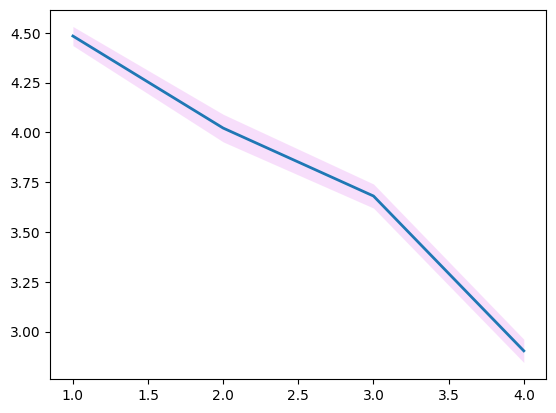

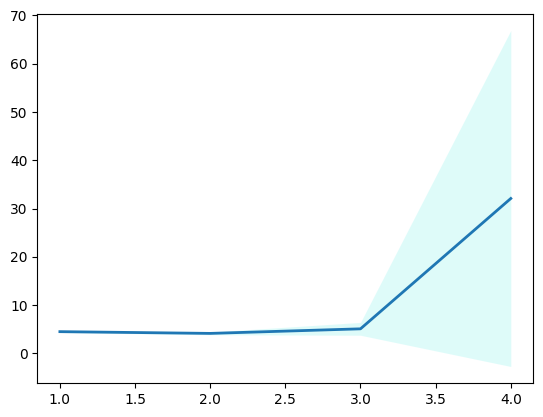

In [62]:


from sklearn.model_selection import validation_curve


mejor_escalador = busqueda.best_params_["escalador"]
# luego definimos un pipeline para la curva de aprendizaje con el mejor escalador ya definimos eso con set_params 
pipeline_para_curva = pipeline_polinomial.set_params(
    escalador=mejor_escalador
)
param_range = [1, 2, 3, 4]

train_scores, val_scores = validation_curve(
    pipeline_para_curva, #el pipeline a usar
    X_train, #datos de entrenamiento
    y_train, #datos de entrenamiento de la variable objetivo
    param_name="polinomio__degree", #el nombre del hiperparametro a variar, en este caso el grado del polinomio
    param_range=param_range, #El rango
    cv=KFold(n_splits=5, shuffle=True, random_state=42), #VOLVEMOS A APLICARLA PORQUE DEBE SER PRIMERO UNA VALIDACION CRUZADA Y  DEBE SER IGUAL A COMO SACAMOS LOS VALORES ANTES 
    scoring="neg_root_mean_squared_error",#RMSE es el que vamos a usar para evaluar el desempeño del modelo, es negativo porque sklearn lo hace asi
    n_jobs=-1 #use todo lo posible de nucleos
)

#ESte tambien nos devuelve los valores negativos porque es un error, por eso se hace el cambio de signo para que sea positivo y tenga sentido

train_rmse = -train_scores
val_rmse   = -val_scores
#print(train_rmse)
#print(val_rmse)
# Estas son listas de listas, cada lista interna tiene los valores de RMSE para cada partición de la validación cruzada, por eso se hace la media y desviación estándar para cada grado de polinomio
#Son todos los rmes que nos dio con cad grado en cada una de las convinaciones del KFOLD
train_rmse_mean = train_rmse.mean(axis=1)
val_rmse_mean   = val_rmse.mean(axis=1)


train_rmse_std = train_rmse.std(axis=1)
val_rmse_std   = val_rmse.std(axis=1)


#Hallaremos el minimo y maximo de la sobra de fill 
y1= train_rmse_mean - train_rmse_std
y2= train_rmse_mean + train_rmse_std

#Usamos la doc de fill_betwen en mathplotlib 
x= param_range
fig, ax = plt.subplots()

ax.fill_between(x, y1, y2, alpha=.5, linewidth=0,color="#F1BFF8")
ax.plot(x, train_rmse_mean, linewidth=2)



plt.show()



y1= val_rmse_mean - val_rmse_std
y2= val_rmse_mean + val_rmse_std

#Usamos la doc de fill_betwen en mathplotlib 
x= param_range
fig, ax = plt.subplots()

ax.fill_between(x, y1, y2, alpha=.5, linewidth=0,color="#BFF8F5")
ax.plot(x, val_rmse_mean, linewidth=2)



plt.show()


El modelo es bastante bueno porque la sombra esta bien pegadita a la linea lo que dice que no depende de las particiones de los datos sino que el modelo es estable :D. Depronto se podría decir que el sobreajuste empieza en el grado 3 en adelante porque desde ahi el RMSE promedio cae más fuerte, diciendo que el RMSE cada vez es más pequeño, los valores estan cada vas más cerca de los esperado; pero lo que nos confirma todo esto es la segunda grafica donde despues del grado 3 la sombra es enorme lo que nos dice que si depende de los datos que se mandan y que hay sospechas de sobreajustes ya que como depende del conjunto de datos que se le mande pues se puede deducir que si los que se manan de entrenamiento son similares a los de validacion se podran tener valores más coherentes; pero igual esta enorme esa sombra en cualquier combinacion mostrando que es sobreajuste. Y que la diferencia entre lo esperado y el valor obtenido es bastantre exagerado muy grandes esos errores. Mostrando qeu aunque los modelos con menor grado tengan un error un poco más grande no se sea tan preciso, no se les quiita el poder predictivo; a diferencia de los de mayor grado que entienden tan bien las variblaes que se las aprenden y su poder predictivo es minimo lo que hace que el modelo dependa de los datos que se le mande y con datos nuevos no conocidos no sabrá que hacer.

## 4.Construcción de modelos de regresión lineal regularizados
### 4.1 Modelo de referencia regresion lineal comun

Antes de regularizar definimos una regresión lineal sobre las mismas nueve variables, con el mismo preprocesamiento y las mismas particiones, para que cualquier diferencia que se encuentre se pueda atribuir únicamente a la penalización. LinearRegression solo explora la estrategia de escalamiento. 

In [63]:
from sklearn.linear_model import Ridge, Lasso

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'rmse': 'neg_root_mean_squared_error',
           'mae':  'neg_mean_absolute_error',
           'r2':   'r2'}


pipeline_ols = Pipeline(steps=[
    ('preparacion', FunctionTransformer(preparar_variables, validate=False)),
    ('imputador',   SimpleImputer(strategy='median')),
    ('escalador',   StandardScaler()),
    ('modelo',      LinearRegression()),
])

param_grid_ols = {
    'escalador': [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_ols = GridSearchCV(estimator=pipeline_ols, 
                        param_grid=param_grid_ols,
                        cv=kfold, 
                        scoring=scoring, 
                        refit='rmse', #esto lo usamos pra optener todos los valores con el scoring pero poder tener el mejor modelo con el RMSE
                        return_train_score=True, 
                        n_jobs=-1)
grid_ols.fit(X_train, y_train)

print("Mejores hiperparámetros sin regularización:", grid_ols.best_params_)
print(f"RMSE en validación cruzada: {-grid_ols.best_score_:.4f} °C")

Mejores hiperparámetros sin regularización: {'escalador': StandardScaler()}
RMSE en validación cruzada: 4.5134 °C


### 4.2Ridge 

Exploramos alpha en potencias de diez, de 0.001 a 1000

In [64]:
pipeline_ridge = Pipeline(steps=[
    ('preparacion', FunctionTransformer(preparar_variables, validate=False)),
    ('imputador',   SimpleImputer(strategy='median')),
    ('escalador',   StandardScaler()),
    ('modelo',      Ridge()),
])

param_grid_ridge = {
    'modelo__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'escalador':     [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_ridge = GridSearchCV(estimator=pipeline_ridge, 
                          param_grid=param_grid_ridge,
                          cv=kfold, 
                          scoring=scoring, 
                          refit='rmse',
                          return_train_score=True, #Con esto le pedimos que nos devuelva todos las calificaciones tanto de vallidacion como de entrenamiento.
                          n_jobs=-1)
grid_ridge.fit(X_train, y_train)

print("Mejores hiperparámetros Ridge:", grid_ridge.best_params_)
print(f"RMSE en validación cruzada: {-grid_ridge.best_score_:.4f} °C")

Mejores hiperparámetros Ridge: {'escalador': MinMaxScaler(), 'modelo__alpha': 0.1}
RMSE en validación cruzada: 4.5133 °C


In [65]:
resultados_ridge = pd.DataFrame(grid_ridge.cv_results_)

tabla_ridge = resultados_ridge[['param_modelo__alpha', 'param_escalador',
                                'mean_train_rmse', 'mean_test_rmse', 'std_test_rmse']].copy()

tabla_ridge['param_escalador'] = tabla_ridge['param_escalador'].apply(lambda e: type(e).__name__)

tabla_ridge['mean_train_rmse'] = -tabla_ridge['mean_train_rmse']
tabla_ridge['mean_test_rmse']  = -tabla_ridge['mean_test_rmse']

display(tabla_ridge.sort_values(['param_modelo__alpha', 'param_escalador']).round(4))

,param_modelo__alpha,param_escalador,mean_train_rmse,mean_test_rmse,std_test_rmse
7,0.001,MinMaxScaler,4.4842,4.5134,0.1906
14,0.001,RobustScaler,4.4842,4.5134,0.1906
0,0.001,StandardScaler,4.4842,4.5134,0.1906
8,0.010,MinMaxScaler,4.4842,4.5133,0.1907
15,0.010,RobustScaler,4.4842,4.5134,0.1906
1,0.010,StandardScaler,4.4842,4.5134,0.1906
9,0.100,MinMaxScaler,4.4843,4.5133,0.1910
16,0.100,RobustScaler,4.4842,4.5134,0.1906
2,0.100,StandardScaler,4.4842,4.5134,0.1906
10,1.000,MinMaxScaler,4.4878,4.5157,0.1939


Ningún valor de alpha mejora el resultado. El RMSE se queda en 4.5134 desde alpha = 0.001 hasta alpha = 10, igual que el modelo sin regularización, y a partir de ahí solo empeora.

Los escaladores sí se diferencian cuando alpha crece, con alpha pequeño los tres dan el mismo número, porque con casi nada de penalización el escalado no afecta al resultado. Pero en alpha = 1000 van de 5.50 a 8.05. MinMaxScaler es el peor, la penalización castiga justamente a los coeficientes grandes.

In [66]:
mejor_ridge = grid_ridge.best_estimator_
coefs_ridge = mejor_ridge.named_steps['modelo'].coef_

coef_ridge_df = pd.DataFrame({'Característica': VARIABLES, 'coef_ridge': coefs_ridge.round(4)})
coef_ridge_df = coef_ridge_df.sort_values('coef_ridge', key=abs, ascending=False).reset_index(drop=True)

print(coef_ridge_df.to_string(index=False))
print(f"\nCoeficientes exactamente en cero: {(coefs_ridge == 0).sum()} de {len(VARIABLES)}")
print(f"Intercepto (no penalizado): {mejor_ridge.named_steps['modelo'].intercept_:.4f}")

Característica  coef_ridge
       dia_cos    -20.3289
  viento_norte    -19.2584
   viento_este      9.6938
 presion_media      7.6922
 humedad_media     -6.2026
       dia_sin     -4.6339
  viento_media     -1.4919
  presion_desv     -1.1444
    rafaga_max     -1.0674

Coeficientes exactamente en cero: 0 de 9
Intercepto (no penalizado): 33.8080


La variable más influyente es dia_cos −20.33, seguida de viento_norte (−19.26), el ciclo del año y la dirección del viento pesan más que la presión o la humedad.

Ningún coeficiente queda en cero. Eso es lo esperado de Ridge, encoge los coeficientes pero nunca los elimina. 

Estos coeficientes vienen del modelo con MinMaxScaler, que fue el ganador. 

In [67]:
mejor_ridge = grid_ridge.best_estimator_

print("--- Ridge ---")
print("TRAIN :", calcular_metricas(mejor_ridge, X_train, y_train))
print("TEST  :", calcular_metricas(mejor_ridge, X_test,  y_test))

--- Ridge ---
TRAIN : {'RMSE': np.float64(4.48775340436537), 'MAE': 3.45138163729853, 'R2': 0.7523498018251967}
TEST  : {'RMSE': np.float64(4.574976618450226), 'MAE': 3.4837953193097837, 'R2': 0.7482060875421115}


Ridge obtiene RMSE de 4.49 °C en entrenamiento y 4.57 °C en prueba, con R^2 de aprox 0.75 en ambos. La diferencia entre los dos conjuntos es muy pequeña, así que el modelo no está sobreajustado.

Eso explica por qué la regularización no mejora nada aquí, sirve para corregir sobreajuste, y este modelo no lo tiene

### 4.3 Lasso

Ahora haremos el mismo proceso pero con lasso, usamos el mismo pipeline pero solo cambiamos el modelo

In [68]:
pipeline_lasso = Pipeline(steps=[
    ('preparacion', FunctionTransformer(preparar_variables, validate=False)),
    ('imputador',   SimpleImputer(strategy='median')),
    ('escalador',   StandardScaler()),
    ('modelo',      Lasso()),
])

param_grid_lasso = {
    'modelo__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'escalador':     [StandardScaler(), MinMaxScaler(), RobustScaler()]}

# SE usa el mismo kfold y scorinig 
#Tambien ponemos como calificacion más importante el rmse y obtenemos tanto los de prueba como los de validacion 

grid_lasso = GridSearchCV(estimator=pipeline_lasso, 
                          param_grid=param_grid_lasso,
                          cv=kfold, 
                          scoring=scoring, 
                          refit='rmse', #esto lo usamos pra optener todos los valores con el scoring pero poder tener el mejor modelo con el RMSE
                          return_train_score=True, 
                          n_jobs=-1)

#Lo probamos con los datos de entrenamiento 
grid_lasso.fit(X_train, y_train)

resultados_lasso = pd.DataFrame(grid_lasso.cv_results_)
display(resultados_lasso[['param_modelo__alpha', 'param_escalador', 'mean_train_rmse', 'mean_test_rmse', 'std_test_rmse']].round(4))

display(resultados_lasso.groupby('param_escalador'))

coefs_lasso = grid_lasso.best_estimator_.named_steps['modelo'].coef_


,param_modelo__alpha,param_escalador,mean_train_rmse,mean_test_rmse,std_test_rmse
0,0.001,StandardScaler(),-4.4842,-4.5133,0.1908
1,0.010,StandardScaler(),-4.4844,-4.5134,0.1919
2,0.100,StandardScaler(),-4.4976,-4.5257,0.2033
3,1.000,StandardScaler(),-5.0818,-5.0932,0.2936
4,10.000,StandardScaler(),-9.0162,-9.0267,0.2880
5,100.000,StandardScaler(),-9.0162,-9.0267,0.2880
6,1000.000,StandardScaler(),-9.0162,-9.0267,0.2880
7,0.001,MinMaxScaler(),-4.4843,-4.5132,0.1916
8,0.010,MinMaxScaler(),-4.4906,-4.5178,0.1998
9,0.100,MinMaxScaler(),-4.7885,-4.8010,0.2624


In [69]:
mejor_lasso = grid_lasso.best_estimator_
rmse_tr, mae_tr, r2_tr = calcular_metricas(mejor_lasso, X_train, y_train).values()
rmse_te, mae_te, r2_te = calcular_metricas(mejor_lasso, X_test, y_test).values()

print("--- Lasso ---")
print("TRAIN :", "RMSE:" + str(round(rmse_tr, 4)), "MAE:" + str(round(mae_tr, 4)), "R2:" + str(round(r2_tr, 4)))
print("TEST  :", "RMSE:" + str(round(rmse_te, 4)), "MAE:" + str(round(mae_te, 4)), "R2:" + str(round(r2_te, 4)))

--- Lasso ---
TRAIN : RMSE:4.4878 MAE:3.4518 R2:0.7523
TEST  : RMSE:4.5757 MAE:3.4846 R2:0.7481


Ahora vamos a ahcer la comparación de todos los mejores resultados para cada modelo.

In [70]:
mejor_lasso = grid_lasso.best_estimator_
mejor_ridge = grid_ridge.best_estimator_
mejor_ols = grid_ols.best_estimator_

rmse_tr_lasso, mae_tr_lasso, r2_tr_lasso = calcular_metricas(mejor_lasso, X_train, y_train).values()
rmse_te_lasso, mae_te_lasso, r2_te_lasso = calcular_metricas(mejor_lasso, X_test, y_test).values()
rmse_tr_ridge, mae_tr_ridge, r2_tr_ridge = calcular_metricas(mejor_ridge, X_train, y_train).values()
rmse_te_ridge, mae_te_ridge, r2_te_ridge = calcular_metricas(mejor_ridge, X_test, y_test).values()
rmse_tr_ols, mae_tr_ols, r2_tr_ols = calcular_metricas(mejor_ols, X_train, y_train).values()
rmse_te_ols, mae_te_ols, r2_te_ols = calcular_metricas(mejor_ols, X_test, y_test).values()

comparacion_modelos = pd.DataFrame({
    'RMSE_train': [rmse_tr_ols, rmse_tr_ridge, rmse_tr_lasso],
    'RMSE_test':  [rmse_te_ols, rmse_te_ridge, rmse_te_lasso],
    'MAE_train':  [mae_tr_ols, mae_tr_ridge, mae_tr_lasso],
    'MAE_test':   [mae_te_ols, mae_te_ridge, mae_te_lasso],
    'R2_train':   [r2_tr_ols, r2_tr_ridge, r2_tr_lasso],
    'R2_test':    [r2_te_ols, r2_te_ridge, r2_te_lasso],
}, index=['OLS', 'Ridge', 'Lasso'])

display(comparacion_modelos.round(4))

,RMSE_train,RMSE_test,MAE_train,MAE_test,R2_train,R2_test
OLS,4.4877,4.5755,3.4512,3.4845,0.7524,0.7481
Ridge,4.4878,4.5750,3.4514,3.4838,0.7523,0.7482
Lasso,4.4878,4.5757,3.4518,3.4846,0.7523,0.7481


Los resultados son practicamente idénticos entre la Regresión Lineal, Ridge y Lasso, alcanzando todos un R2 de 0.7481 y un RMSE cercano a 4.57 tanto en entrenamiento como en prueba. La mínima diferencia entre las métricas de entrenamiento y validación demuestra que el modelo base no sufría de sobreajuste ni de multicolinealidad severa, por lo que aplicar una penalización L1 o L_2 no aporta ninguna mejora en la capacidad de generalización. Podemos ver que las variables que seleccioonamos para el modelos estuvieron super bien porque todas son importante de gran utilidad uy sin mucha multicolinealildad lo que hace el modelo solito con regresiono lineal bastante bueno :D

## 5.  Construcción de un modelo de regresión polinomial regularizado

Combinamos las dos ideas anteriores en un solo pipeline, PolynomialFeatures genera los términos de grado alto y Ridge penaliza los coeficientes que esos términos producen. Ahora la búsqueda tiene tres hiperparámetros que son el grado del polinomio, el parámetro de penalización alpha y la estrategia de escalamiento.
En el punto 2 observamos que los grados 3 y 4 colapsaron con RMSE muy elevados por los coeficientes, la idea es que Ridge nos ayude a impedir eso. 

### 5.1 Ridge

In [71]:
pipeline_poli_ridge = Pipeline(steps=[
    ('preparacion', FunctionTransformer(preparar_variables, validate=False)),
    ('imputador',   SimpleImputer(strategy='median')),
    ('escalador',   StandardScaler()),
    ('polinomio',   PolynomialFeatures(include_bias=False)),
    ('modelo',      Ridge()),
])

param_grid_poli_ridge = {
    'polinomio__degree': [1, 2, 3, 4],
    'modelo__alpha':     [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'escalador':         [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_poli_ridge = GridSearchCV(estimator=pipeline_poli_ridge, param_grid=param_grid_poli_ridge,
                               cv=kfold, scoring=scoring, refit='rmse',
                               return_train_score=True, n_jobs=-1)
grid_poli_ridge.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_poli_ridge.best_params_)
print(f"RMSE en validación cruzada: {-grid_poli_ridge.best_score_:.4f} °C")

Mejores hiperparámetros: {'escalador': MinMaxScaler(), 'modelo__alpha': 1, 'polinomio__degree': 4}
RMSE en validación cruzada: 4.1157 °C


In [72]:
resultados_pr = pd.DataFrame(grid_poli_ridge.cv_results_)

tabla_pr = resultados_pr[['param_polinomio__degree', 'param_modelo__alpha', 'param_escalador',
                          'mean_train_rmse', 'mean_test_rmse', 'std_test_rmse']].copy()

tabla_pr['param_escalador'] = tabla_pr['param_escalador'].apply(lambda e: type(e).__name__)
tabla_pr['mean_train_rmse'] = -tabla_pr['mean_train_rmse']
tabla_pr['mean_test_rmse']  = -tabla_pr['mean_test_rmse']

display(tabla_pr.sort_values('mean_test_rmse').round(4).head(10))

,param_polinomio__degree,param_modelo__alpha,param_escalador,mean_train_rmse,mean_test_rmse,std_test_rmse
43,4,1.000,MinMaxScaler,3.9250,4.1157,0.2841
42,3,1.000,MinMaxScaler,4.0069,4.1210,0.2696
38,3,0.100,MinMaxScaler,3.8832,4.1288,0.2860
37,2,0.100,MinMaxScaler,4.0393,4.1432,0.2732
33,2,0.010,MinMaxScaler,4.0228,4.1454,0.2769
17,2,10.000,StandardScaler,4.0230,4.1489,0.2767
69,2,1.000,RobustScaler,4.0221,4.1496,0.2751
29,2,0.001,MinMaxScaler,4.0220,4.1500,0.2752
13,2,1.000,StandardScaler,4.0220,4.1504,0.2751
65,2,0.100,RobustScaler,4.0220,4.1506,0.2749


La mejor combinación es grado 4, alpha = 1 y MinMaxScaler, con un RMSE de 4.1157 en validación cruzada.
En el punto 2, sin regularización, el grado 3 daba 5.0980 y el grado 4 daba 32.0959. Con Ridge, ambos quedan al nivel del grado 2. Esto responde la pregunta del enunciado donde concluimos que la regularización sí controla el sobreajuste al aumentar la complejidad.
Finalmente, la diferencia entre mean_train_rmse y mean_test_rmse es pequeña en todas las filas lo que confirma que ya no queda sobreajuste.

In [73]:
mejor_pr = grid_poli_ridge.best_estimator_

m_train = calcular_metricas(mejor_pr, X_train, y_train)
m_test  = calcular_metricas(mejor_pr, X_test,  y_test)

print("TRAIN | RMSE:", round(m_train['RMSE'], 4), "| MAE:", round(m_train['MAE'], 4), "| R2:", round(m_train['R2'], 4))
print("TEST  | RMSE:", round(m_test['RMSE'], 4),  "| MAE:", round(m_test['MAE'], 4),  "| R2:", round(m_test['R2'], 4))
print("Características generadas:", mejor_pr.named_steps['polinomio'].n_output_features_)

TRAIN | RMSE: 3.9405 | MAE: 2.9986 | R2: 0.8091
TEST  | RMSE: 4.2132 | MAE: 3.2277 | R2: 0.7865
Características generadas: 714


El mejor modelo es grado 4 con MinMaxScaler y alpha = 1, con RMSE de 4.1157 en validación cruzada y 4.2132 en prueba como se vio en los 

### 5.2 Lasso

In [74]:
pipeline_polinomial = Pipeline([
    ('preparacion', FunctionTransformer(preparar_variables, validate=False)),
    ('imputador',   SimpleImputer(strategy='median')),
    ('escalador',   StandardScaler()),                                  
    ('polinomio',   PolynomialFeatures(degree=2, include_bias=False)),  
    ('modelo',      Lasso()),
])

param_grid_lasso = {
    'modelo__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'escalador':     [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'polinomio__degree': [1, 2, 3]
}


grid_poli_lasso = GridSearchCV(estimator=pipeline_polinomial, 
                          param_grid=param_grid_lasso,
                          cv=kfold, 
                          scoring=scoring, 
                          refit='rmse', #esto lo usamos pra optener todos los valores con el scoring pero poder tener el mejor modelo con el RMSE
                          return_train_score=True, 
                          n_jobs=-1)

grid_poli_lasso.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_poli_lasso.best_params_)
print(f"RMSE en validación cruzada: {-grid_poli_lasso.best_score_:.4f} °C")

resultados_poli = pd.DataFrame(grid_poli_lasso.cv_results_)
display(resultados_poli[['param_modelo__alpha', 'param_escalador', 'mean_train_rmse', 'mean_test_rmse', 'std_test_rmse']].round(4))


Mejores hiperparámetros: {'escalador': MinMaxScaler(), 'modelo__alpha': 0.001, 'polinomio__degree': 3}
RMSE en validación cruzada: 4.1038 °C


C:\Users\lauri\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.152327e+03, tolerance: 1.497e+01
  model = cd_fast.enet_coordinate_descent(


,param_modelo__alpha,param_escalador,mean_train_rmse,mean_test_rmse,std_test_rmse
0,0.001,StandardScaler(),-4.4842,-4.5133,0.1908
1,0.001,StandardScaler(),-4.0220,-4.1495,0.2748
2,0.001,StandardScaler(),-3.6811,-5.0450,1.2490
3,0.010,StandardScaler(),-4.4844,-4.5134,0.1919
4,0.010,StandardScaler(),-4.0236,-4.1409,0.2746
...,...,...,...,...,...
58,100.000,RobustScaler(),-9.0162,-9.0267,0.2880
59,100.000,RobustScaler(),-9.0162,-9.0267,0.2880
60,1000.000,RobustScaler(),-9.0162,-9.0267,0.2880
61,1000.000,RobustScaler(),-9.0162,-9.0267,0.2880


Vamos a pasar los RMSE a positivos tanto los de entrenamiento como los de test y vamos a ordenar los valores del RMSE para obtener los de menot error  en la media del  rmse

In [75]:
resultados_pl= pd.DataFrame(grid_poli_lasso.cv_results_)

tabla_pl = resultados_pl[['param_polinomio__degree', 'param_modelo__alpha', 'param_escalador',
                          'mean_train_rmse', 'mean_test_rmse', 'std_test_rmse']].copy()

tabla_pl['param_escalador'] = tabla_pl['param_escalador'].apply(lambda e: type(e).__name__)
tabla_pl['mean_train_rmse'] = -tabla_pl['mean_train_rmse']
tabla_pl['mean_test_rmse']  = -tabla_pl['mean_test_rmse']

display(tabla_pl.sort_values('mean_test_rmse').round(4).head(10))

,param_polinomio__degree,param_modelo__alpha,param_escalador,mean_train_rmse,mean_test_rmse,std_test_rmse
23,3,0.001,MinMaxScaler,3.9386,4.1038,0.2733
22,2,0.001,MinMaxScaler,4.0423,4.1359,0.2716
46,2,0.010,RobustScaler,4.0272,4.1395,0.2703
4,2,0.010,StandardScaler,4.0236,4.1409,0.2746
43,2,0.001,RobustScaler,4.0220,4.1486,0.2746
1,2,0.001,StandardScaler,4.0220,4.1495,0.2748
7,2,0.100,StandardScaler,4.0919,4.1623,0.2463
26,3,0.010,MinMaxScaler,4.1560,4.2127,0.2601
8,3,0.100,StandardScaler,3.9469,4.2329,0.3053
49,2,0.100,RobustScaler,4.1800,4.2348,0.2106


In [ ]:
mejor_pr = grid_poli_lasso.best_estimator_

m_train = calcular_metricas(mejor_pr, X_train, y_train)
m_test  = calcular_metricas(mejor_pr, X_test,  y_test)

print("TRAIN | RMSE:", round(m_train['RMSE'], 4), "| MAE:", round(m_train['MAE'], 4), "| R2:", round(m_train['R2'], 4))
print("TEST  | RMSE:", round(m_test['RMSE'], 4),  "| MAE:", round(m_test['MAE'], 4),  "| R2:", round(m_test['R2'], 4))
print("Características generadas:", mejor_pr.named_steps['polinomio'].n_output_features_)

TRAIN | RMSE: 3.9664 | MAE: 3.0205 | R2: 0.8065
TEST  | RMSE: 4.1987 | MAE: 3.2059 | R2: 0.7879
Características generadas: 219


## 6. Comparacioon y seleccion del mejor modelo.

Como hicimos en el punto anterior vamos a coger los mejores resultados de cada uno de los modelos utilizados y con eso hacer una tabla donde primero vamos a comparar valor promedio del error; y también con las devisaciones estandar para las estabilidades y sobreajustes del modelo con validacion cruzada

In [80]:

# Encontramos la posición del mejor modelo
idx_lasso = grid_lasso.best_index_
idx_ridge = grid_ridge.best_index_
idx_ols = grid_ols.best_index_
idx_pr = grid_poli_ridge.best_index_
idx_pl = grid_poli_lasso.best_index_
idx_poli = busqueda.best_index_


promedio_rmse_lasso = -grid_lasso.cv_results_['mean_test_rmse'][idx_lasso]
desviacion_rmse_lasso = grid_lasso.cv_results_['std_test_rmse'][idx_lasso]

promedio_rmse_ridge = -grid_ridge.cv_results_['mean_test_rmse'][idx_ridge]
desviacion_rmse_ridge = grid_ridge.cv_results_['std_test_rmse'][idx_ridge]

promedio_rmse_ols = -grid_ols.cv_results_['mean_test_rmse'][idx_ols]
desviacion_rmse_ols = grid_ols.cv_results_['std_test_rmse'][idx_ols]

promedio_rmse_pr = -grid_poli_ridge.cv_results_['mean_test_rmse'][idx_pr]
desviacion_rmse_pr = grid_poli_ridge.cv_results_['std_test_rmse'][idx_pr]

promedio_rmse_pl = -grid_poli_lasso.cv_results_['mean_test_rmse'][idx_pl]
desviacion_rmse_pl = grid_poli_lasso.cv_results_['std_test_rmse'][idx_pl]

promedio_rmse_poli = -busqueda.cv_results_['mean_test_rmse'][idx_poli]
desviacion_rmse_poli = busqueda.cv_results_['std_test_rmse'][idx_poli]



comparacion_modelos = pd.DataFrame({
    'RMSE_mean_train': [promedio_rmse_ols, promedio_rmse_ridge, promedio_rmse_lasso, promedio_rmse_poli,promedio_rmse_pr, promedio_rmse_pl],
    'std_train':  [desviacion_rmse_ols, desviacion_rmse_ridge, desviacion_rmse_lasso, desviacion_rmse_poli, desviacion_rmse_pr, desviacion_rmse_pl],
    'RMSE_mean_test':  [promedio_rmse_ols, promedio_rmse_ridge, promedio_rmse_lasso, promedio_rmse_poli, promedio_rmse_pr, promedio_rmse_pl],
    'std_test':   [desviacion_rmse_ols, desviacion_rmse_ridge, desviacion_rmse_lasso, desviacion_rmse_poli, desviacion_rmse_pr, desviacion_rmse_pl]
}, index=['OLS', 'Ridge', 'Lasso', 'Polinomial', 'Polinomial Ridge', 'Polinomial Lasso'])

display(comparacion_modelos.round(4))

,RMSE_mean_train,std_train,RMSE_mean_test,std_test
OLS,4.5134,0.1906,4.5134,0.1906
Ridge,4.5133,0.1910,4.5133,0.1910
Lasso,4.5132,0.1916,4.5132,0.1916
Polinomial,4.1507,0.2749,4.1507,0.2749
Polinomial Ridge,4.1157,0.2841,4.1157,0.2841
Polinomial Lasso,4.1038,0.2733,4.1038,0.2733


Analisis resultados y mejor modelo 